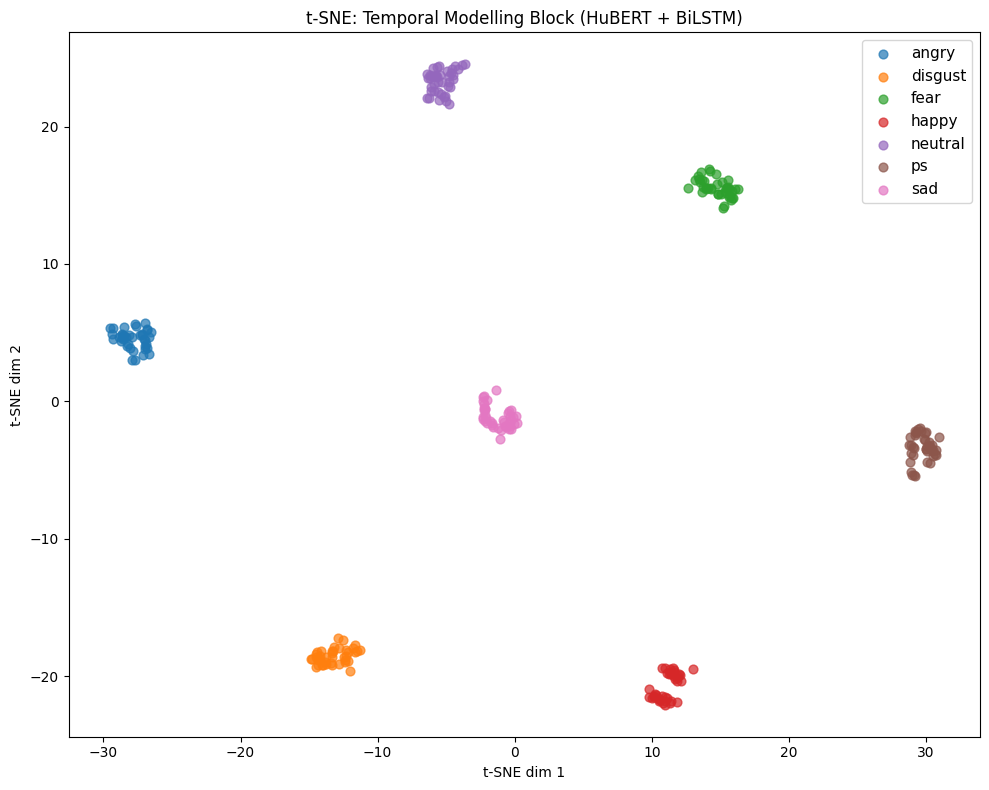

Saved: tsne_temporal.png


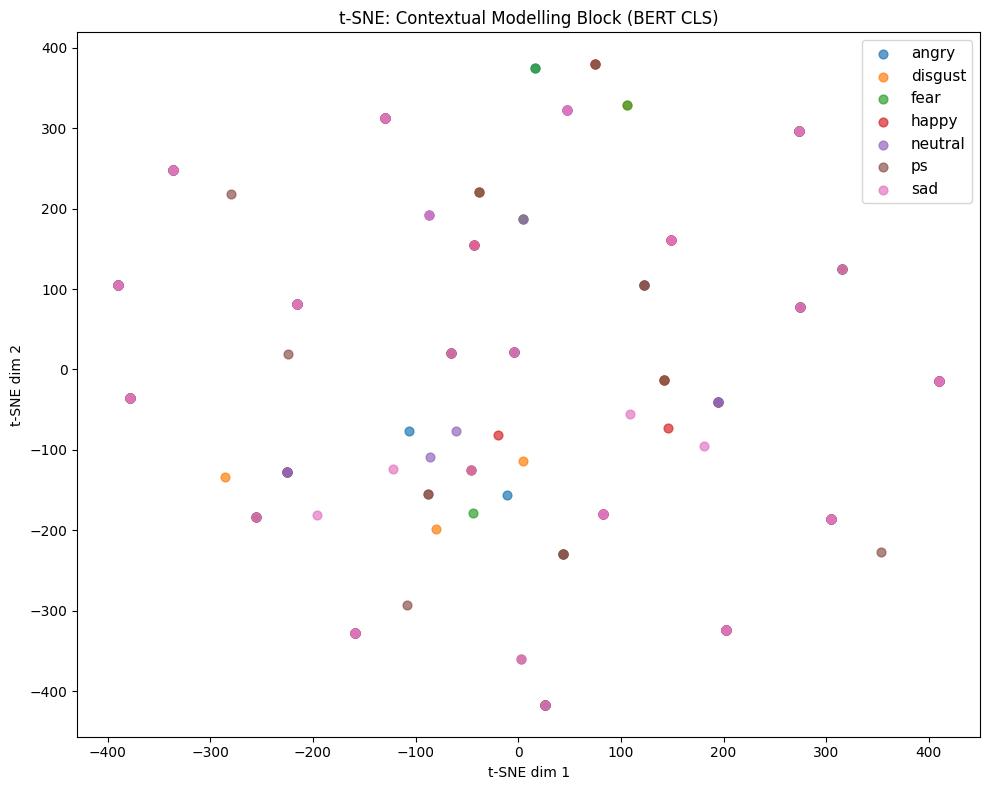

Saved: tsne_contextual.png


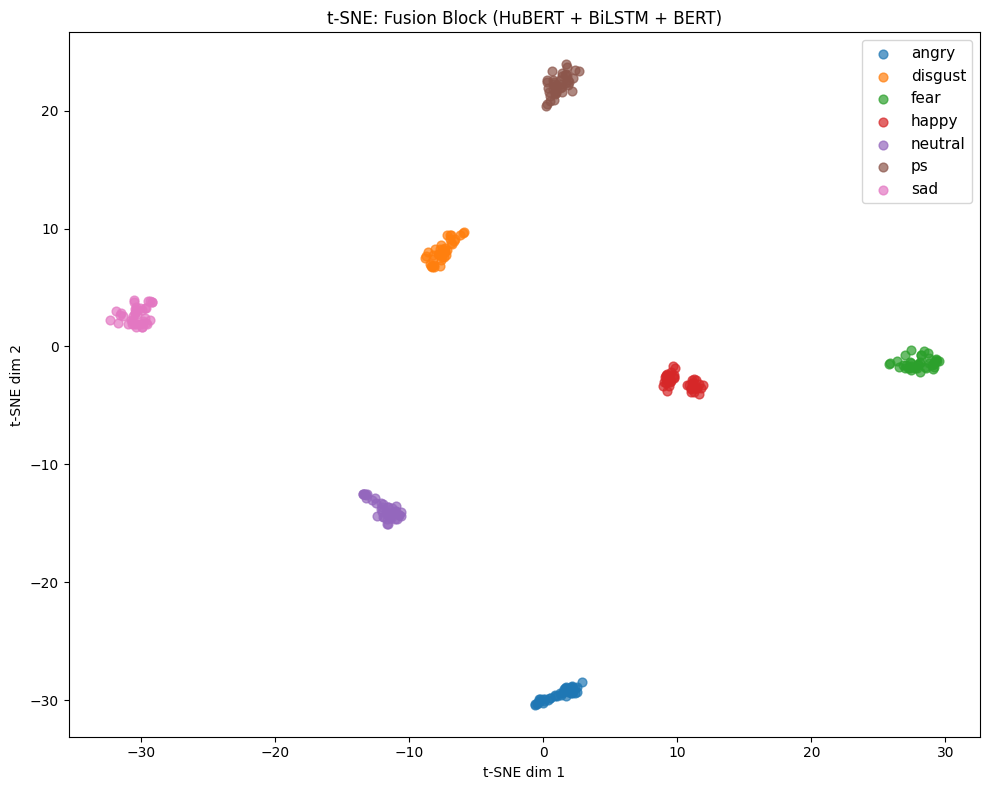

Saved: tsne_fusion.png


In [2]:
# IMPORTS

import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns


# LOAD TEST FEATURES

X_test_speech = np.memmap(
    "/content/drive/MyDrive/tess_hubert_features/X_test_hubert.npy",
    dtype="float32",
    mode="r",
    shape=(280, 200, 768)
)

X_test_text = np.memmap(
    "/content/drive/MyDrive/tess_bert_features/X_test_bert.npy",
    dtype="float32",
    mode="r",
    shape=(280, 768)
)

y_test = np.memmap(
    "/content/drive/MyDrive/tess_hubert_features/y_test_hubert.npy",
    dtype="int32",
    mode="r",
    shape=(280,)
)


# DATALOADER

X_test_speech = torch.tensor(
    X_test_speech,
    dtype=torch.float32
)

X_test_text = torch.tensor(
    X_test_text,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

test_loader = DataLoader(
    TensorDataset(
        X_test_speech,
        X_test_text,
        y_test_tensor
    ),
    batch_size=32,
    shuffle=False
)


# LABELS

emotion_names = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'ps',
    'sad'
]

colors = sns.color_palette(
    "tab10",
    7
)


# DEVICE

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# BILSTM ENCODER

class BiLSTMEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        num_layers=2
    ):

        super().__init__()

        self.bilstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.out_dim = hidden_dim * 2

    def forward(self, x):

        out, _ = self.bilstm(x)

        return out.mean(dim=1)


# CLASSIFIER

class EmotionClassifier(nn.Module):

    def __init__(
        self,
        encoder,
        num_classes=7
    ):

        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Sequential(

            nn.Linear(
                encoder.out_dim,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.encoder(x)

        return self.classifier(x)


# CORRECT FUSION MODEL

class LateFusionModel(nn.Module):

    def __init__(
        self,
        speech_input_dim=768,
        speech_hidden_dim=128,
        text_dim=768,
        fusion_dim=256,
        num_classes=7
    ):

        super().__init__()

        self.speech_encoder = BiLSTMEncoder(
            input_dim=speech_input_dim,
            hidden_dim=speech_hidden_dim
        )

        self.text_projection = nn.Sequential(

            nn.Linear(
                text_dim,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3)
        )

        self.fusion_fc = nn.Linear(
            512,
            fusion_dim
        )

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(
                fusion_dim,
                128
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, speech_feat, text_feat):

        s = self.speech_encoder(
            speech_feat
        )

        t = self.text_projection(
            text_feat
        )

        fused = self.fusion_fc(
            torch.cat([s, t], dim=-1)
        )

        return self.classifier(fused)


# TSNE FUNCTION

def plot_tsne(
    representations,
    labels,
    title,
    save_path
):

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        max_iter=1000
    )

    reduced = tsne.fit_transform(
        representations
    )

    plt.figure(figsize=(10, 8))

    for i, name in enumerate(emotion_names):

        mask = labels == i

        plt.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            label=name,
            alpha=0.7,
            s=40,
            color=colors[i]
        )

    plt.legend(fontsize=11)

    plt.title(title)

    plt.xlabel("t-SNE dim 1")

    plt.ylabel("t-SNE dim 2")

    plt.tight_layout()

    plt.savefig(save_path, dpi=150)

    plt.show()

    print("Saved:", save_path)


# LOAD HUBERT MODEL

encoder = BiLSTMEncoder(
    input_dim=768
)

speech_model = EmotionClassifier(
    encoder
)

speech_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/tess_models_hubert/bilstm_hubert.pth",
        map_location=device
    )
)

speech_model.to(device)

speech_model.eval()


# EXTRACT SPEECH REPRESENTATIONS

speech_reps = []

with torch.no_grad():

    for X_s, X_t, y_b in test_loader:

        X_s = X_s.to(device)

        rep = speech_model.encoder(X_s)

        speech_reps.append(
            rep.cpu().numpy()
        )

speech_reps = np.concatenate(
    speech_reps
)


# SPEECH TSNE

plot_tsne(
    speech_reps,
    np.array(y_test),
    "t-SNE: Temporal Modelling Block (HuBERT + BiLSTM)",
    "tsne_temporal.png"
)


# TEXT TSNE

text_reps = np.array(
    X_test_text
)

plot_tsne(
    text_reps,
    np.array(y_test),
    "t-SNE: Contextual Modelling Block (BERT CLS)",
    "tsne_contextual.png"
)


# LOAD FUSION MODEL

fusion_model = LateFusionModel()

fusion_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/tess_models_fusion/hubert_bilstm_bert_latefusion_tess.pth",
        map_location=device
    )
)

fusion_model.to(device)

fusion_model.eval()


# EXTRACT FUSION REPRESENTATIONS

fusion_reps = []

with torch.no_grad():

    for X_s, X_t, y_b in test_loader:

        X_s = X_s.to(device)

        X_t = X_t.to(device)

        s = fusion_model.speech_encoder(
            X_s
        )

        t = fusion_model.text_projection(
            X_t
        )

        fused = fusion_model.fusion_fc(
            torch.cat([s, t], dim=-1)
        )

        fusion_reps.append(
            fused.cpu().numpy()
        )

fusion_reps = np.concatenate(
    fusion_reps
)


# FUSION TSNE

plot_tsne(
    fusion_reps,
    np.array(y_test),
    "t-SNE: Fusion Block (HuBERT + BiLSTM + BERT)",
    "tsne_fusion.png"
)